# Loaded the dataset

In [1]:
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
from ml.src.data.load_data import load_raw


df = load_raw("D:\\HealthForecastAI\\ml\\data\\raw\\diabetic_data.csv")

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# EDA Analysis

In [3]:
print("Dataset shape:", df.shape)


Dataset shape: (101766, 50)


In [4]:
print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


Column names:
1. encounter_id
2. patient_nbr
3. race
4. gender
5. age
6. weight
7. admission_type_id
8. discharge_disposition_id
9. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

# Checking null values 

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


# Check duplicate values

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Duplicate encounter IDs:", df["encounter_id"].duplicated().sum())

Duplicate encounter IDs: 0


# Target variable analyze

In [10]:
print("Readmission categories:")
print(df["readmitted"].value_counts())

Readmission categories:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [11]:
print("\nReadmission percentage:")
print(df["readmitted"].value_counts(normalize=True).mul(100).round(2))


Readmission percentage:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


# Categorical columns identify


In [13]:
categorical_cols = df.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical columns:")
print(categorical_cols.tolist())

Number of categorical columns: 37

Categorical columns:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


# Distribution of categorical features

In [14]:
categorical_analysis_cols = [
    "race",
    "gender",
    "age",
    "diabetesMed",
    "change"
]

for col in categorical_analysis_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- race ---
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- diabetesMed ---
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

--- change ---
change
No    54755
Ch    47011
Name: count, dtype: int64


# Analyze the medications

In [15]:
medication_cols = [
    "metformin",
    "insulin",
    "glipizide",
    "glyburide"
]

for col in medication_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- metformin ---
metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

--- insulin ---
insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

--- glipizide ---
glipizide
No        89080
Steady    11356
Up          770
Down        560
Name: count, dtype: int64

--- glyburide ---
glyburide
No        91116
Steady     9274
Up          812
Down        564
Name: count, dtype: int64


# Analyze diagnosis columns 

In [16]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    print(f"{col}:")
    print("Unique values:", df[col].nunique(dropna=True))
    print()

diag_1:
Unique values: 716

diag_2:
Unique values: 748

diag_3:
Unique values: 789



In [17]:
for col in diagnosis_cols:
    print(f"\n--- Top 10 {col} diagnoses ---")
    print(df[col].value_counts(dropna=True).head(10))


--- Top 10 diag_1 diagnoses ---
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

--- Top 10 diag_2 diagnoses ---
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

--- Top 10 diag_3 diagnoses ---
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64


analysis — Hospital stay vs readmission

In [18]:
df.groupby("readmitted")["time_in_hospital"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
readmitted,,,
<30,11357,4.768249,4.0
>30,35545,4.495541,4.0
NO,54864,4.254429,3.0


In [19]:
df.groupby("readmitted")["number_emergency"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
readmitted,,,,
<30,11357,0.357313,0.0,64
>30,35545,0.283669,0.0,76
NO,54864,0.109216,0.0,37


In [20]:
print(df["number_emergency"].describe())

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64


In [21]:
print(df.groupby("readmitted")["number_emergency"].mean())

readmitted
<30    0.357313
>30    0.283669
NO     0.109216
Name: number_emergency, dtype: float64


In [22]:
print("Are number_emergency and number_inpatient identical?")
print(df["number_emergency"].equals(df["number_inpatient"]))

Are number_emergency and number_inpatient identical?
False


In [23]:
print(df[["number_inpatient", "number_emergency"]].head(20))

    number_inpatient  number_emergency
0                  0                 0
1                  0                 0
2                  1                 0
3                  0                 0
4                  0                 0
5                  0                 0
6                  0                 0
7                  0                 0
8                  0                 0
9                  0                 0
10                 0                 0
11                 0                 0
12                 0                 1
13                 0                 0
14                 0                 0
15                 0                 0
16                 0                 0
17                 0                 0
18                 0                 0
19                 0                 0


In [24]:
print(
    df.groupby("readmitted")[["number_inpatient", "number_emergency"]].mean()
)

            number_inpatient  number_emergency
readmitted                                    
<30                 1.224003          0.357313
>30                 0.838993          0.283669
NO                  0.381963          0.109216


# Age group vs 30-day readmission

In [25]:
age_readmission = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
) * 100

age_readmission.round(2)

readmitted,<30,>30,NO
age,,,
[0-10),1.86,16.15,81.99
[10-20),5.79,32.42,61.79
[20-30),14.24,30.78,54.98
[30-40),11.23,31.44,57.32
[40-50),10.60,33.85,55.55
[50-60),9.67,34.29,56.04
[60-70),11.13,35.12,53.75
[70-80),11.77,36.35,51.88
[80-90),12.08,36.19,51.73


# Visualization - Bar chart

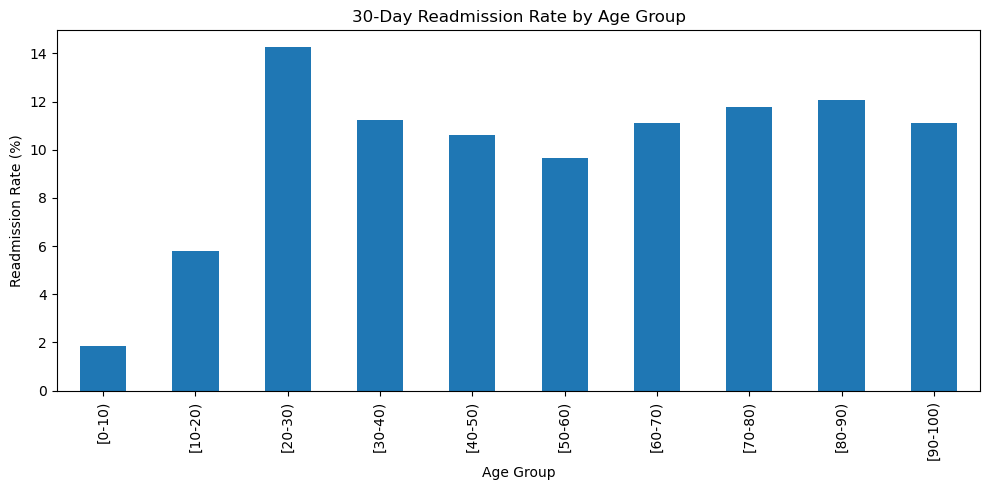

In [26]:
age_readmission["<30"].plot(
    kind="bar",
    figsize=(10, 5),
    title="30-Day Readmission Rate by Age Group",
    ylabel="Readmission Rate (%)",
    xlabel="Age Group"
)

plt.tight_layout()
plt.show()

 ### EDA Finding: Age and 30-Day Readmission

The 30-day readmission rate varies across age groups. The [20-30) age group has the highest observed 30-day readmission rate at 14.24%, while the [0-10) group has the lowest at 1.86%. Most older adult age groups show 30-day readmission rates around 10-12%.

These results indicate that age may contain useful information for readmission prediction, although the observed association does not imply causation.

In [27]:
df.groupby("readmitted")["num_medications"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
readmitted,,,,
<30,11357,16.903143,16.0,81
>30,35545,16.282768,15.0,70
NO,54864,15.670367,14.0,79


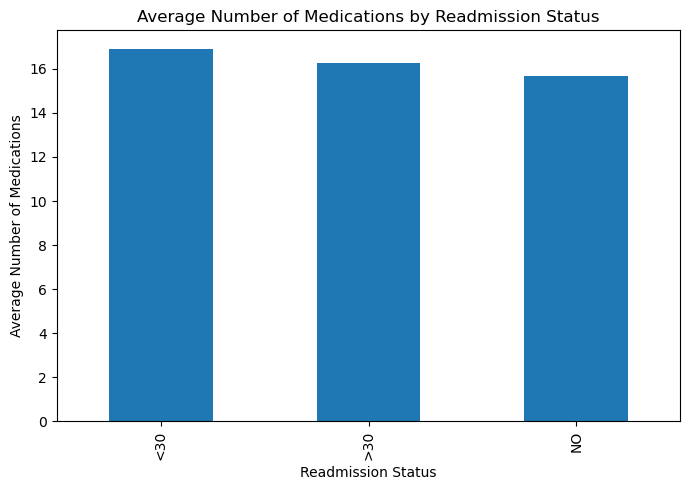

In [28]:
med_readmission = df.groupby("readmitted")["num_medications"].mean()

med_readmission.plot(
    kind="bar",
    figsize=(7, 5),
    title="Average Number of Medications by Readmission Status",
    ylabel="Average Number of Medications",
    xlabel="Readmission Status"
)

plt.tight_layout()
plt.show()

### EDA Finding: Medication Count and Readmission

The average number of medications is highest among patients readmitted within 30 days (16.90), followed by patients readmitted after 30 days (16.28), and patients with no readmission (15.67). This suggests a potential association between medication burden and readmission status, although this analysis does not establish causation.

# Initial cleaning

In [29]:
from ml.src.data.preprocess import remove_expired_patients

In [30]:
before = len(df)

df_no_expired = remove_expired_patients(df)

after = len(df_no_expired)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 101766
Rows after: 100114
Rows removed: 1652


In [31]:
print(
    df_no_expired["discharge_disposition_id"]
    .isin([11, 19, 20, 21])
    .sum()
)

0


# Next step 
Connect the function to the basic ml pipeline 


In [32]:
def basic_clean(frame, config):
    preprocessing = config.get("preprocessing", {})
    cleaned = drop_unused_columns(
        frame,
        preprocessing.get("drop_columns", [])
    )
    return cleaned.drop_duplicates()

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

In [5]:
import pandas as pd

df = pd.read_csv("D:\\HealthForecastAI\\ml\\data\\raw\\diabetic_data.csv")

print(df.shape)

(101766, 50)


In [7]:
from ml.src.data.preprocess import basic_clean

In [9]:
cleaned_df = basic_clean(df, config)

print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)
print("Remaining columns:", len(cleaned_df.columns))

Original shape: (101766, 50)
Cleaned shape: (100114, 45)
Remaining columns: 45


In [8]:
import yaml

with open("D:\\HealthForecastAI\\ml\\configs\\config.yaml", "r") as f:
    config = yaml.safe_load(f)

cleaned_df = basic_clean(df, config)

print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)
print("Remaining columns:", len(cleaned_df.columns))

Original shape: (101766, 50)
Cleaned shape: (100114, 45)
Remaining columns: 45


In [38]:
print(len(df_no_expired))
print(len(cleaned_df))

100114
101766


# Initial cleaning completed 
Expired-patient records removed — 1,652 rows

Unnecessary/high-missing columns droped — 5 columns

to  remoce duplicate rows it is in the basic clean()

# Preprocessing started

In [10]:
# Convert readmission target into binary format

df_processed = cleaned_df.copy()

df_processed["readmitted_binary"] = (
    df_processed["readmitted"].astype(str).str.strip() == "<30"
).astype(int)

print(df_processed["readmitted_binary"].value_counts())
print("\nTarget percentage:")
print(df_processed["readmitted_binary"].value_counts(normalize=True).mul(100).round(2))

readmitted_binary
0    88757
1    11357
Name: count, dtype: int64

Target percentage:
readmitted_binary
0    88.66
1    11.34
Name: proportion, dtype: float64


In [11]:
# Replace original target with binary target

df_processed = df_processed.drop(columns=["readmitted"])

df_processed = df_processed.rename(
    columns={"readmitted_binary": "readmitted"}
)

print(df_processed["readmitted"].value_counts())
print(df_processed.shape)

readmitted
0    88757
1    11357
Name: count, dtype: int64
(100114, 45)


# checking missing values

In [12]:
# Check missing values in the processed dataset

missing = df_processed.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nTotal missing values:", df_processed.isnull().sum().sum())

Columns with missing values:
max_glu_serum    94890
A1Cresult        83238
dtype: int64

Total missing values: 178128


In [13]:
print("--- max_glu_serum ---")
print(df_processed["max_glu_serum"].value_counts(dropna=False))

print("\n--- A1Cresult ---")
print(df_processed["A1Cresult"].value_counts(dropna=False))

--- max_glu_serum ---
max_glu_serum
NaN     94890
Norm     2573
>200     1440
>300     1211
Name: count, dtype: int64

--- A1Cresult ---
A1Cresult
NaN     83238
>8       8151
Norm     4941
>7       3784
Name: count, dtype: int64


# identifgy most frequent values

In [14]:
# Check the most frequent value for categorical missing columns

for column in ["max_glu_serum", "A1Cresult"]:
    print(f"{column}: {df_processed[column].mode()[0]}")

max_glu_serum: Norm
A1Cresult: >8


In [15]:
# Impute missing categorical values using the most frequent value

for column in ["max_glu_serum", "A1Cresult"]:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].mode()[0]
    )

print("Remaining missing values:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [16]:
# Identify numeric and categorical features

numeric_columns = df_processed.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = df_processed.select_dtypes(
    exclude=["number"]
).columns.tolist()

# Remove target from feature columns
numeric_columns.remove("readmitted")

print("Numeric columns:", len(numeric_columns))
print(numeric_columns)

print("\nCategorical columns:", len(categorical_columns))
print(categorical_columns)

Numeric columns: 11
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns: 33
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [17]:
# Check frequency of diagnosis codes

for column in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n{column}")
    print("Unique values:", df_processed[column].nunique())
    print("Rare values (appearing <= 10 times):",
          (df_processed[column].value_counts() <= 10).sum())


diag_1
Unique values: 716
Rare values (appearing <= 10 times): 334

diag_2
Unique values: 748
Rare values (appearing <= 10 times): 386

diag_3
Unique values: 788
Rare values (appearing <= 10 times): 407


In [18]:
# Percentage of records containing rare diagnosis codes

for column in ["diag_1", "diag_2", "diag_3"]:
    counts = df_processed[column].value_counts()
    rare_codes = counts[counts <= 10].index

    rare_mask = df_processed[column].isin(rare_codes)

    print(f"\n{column}")
    print("Rows with rare codes:", rare_mask.sum())
    print("Percentage:", round(rare_mask.mean() * 100, 2), "%")


diag_1
Rows with rare codes: 1296
Percentage: 1.29 %

diag_2
Rows with rare codes: 1381
Percentage: 1.38 %

diag_3
Rows with rare codes: 1511
Percentage: 1.51 %


In [19]:
# Collapse rare diagnosis codes into "Other"

diagnosis_columns = ["diag_1", "diag_2", "diag_3"]

for column in diagnosis_columns:
    counts = df_processed[column].value_counts()
    rare_codes = counts[counts <= 10].index

    df_processed[column] = df_processed[column].replace(
        rare_codes, "Other"
    )

# Verify the result
for column in diagnosis_columns:
    print(f"\n{column}")
    print("Unique values after grouping:", df_processed[column].nunique())
    print(df_processed[column].value_counts().tail())


diag_1
Unique values after grouping: 383
diag_1
54     11
892    11
244    11
263    11
521    11
Name: count, dtype: int64

diag_2
Unique values after grouping: 363
diag_2
250.2    11
737      11
517      11
514      11
693      11
Name: count, dtype: int64

diag_3
Unique values after grouping: 382
diag_3
916    11
351    11
656    11
694    11
317    11
Name: count, dtype: int64


In [20]:
# Check for '?' missing-value tokens

question_mark_counts = {}

for column in categorical_columns:
    count = (df_processed[column] == "?").sum()
    if count > 0:
        question_mark_counts[column] = count

print("Columns containing '?' token:")
print(question_mark_counts)

Columns containing '?' token:
{'race': np.int64(2239), 'diag_1': np.int64(21), 'diag_2': np.int64(358), 'diag_3': np.int64(1421)}


In [21]:
question_mark_counts = {}

for column in categorical_columns:
    count = (df_processed[column] == "?").sum()
    if count > 0:
        question_mark_counts[column] = count

print("Columns containing '?' token:")
print(question_mark_counts)

Columns containing '?' token:
{'race': np.int64(2239), 'diag_1': np.int64(21), 'diag_2': np.int64(358), 'diag_3': np.int64(1421)}


In [22]:
# Convert the configured missing-value token '?' into NaN

df_processed = df_processed.replace("?", pd.NA)

# Check again
question_mark_counts = {}

for column in categorical_columns:
    count = (df_processed[column] == "?").sum()
    if count > 0:
        question_mark_counts[column] = count

print("Remaining '?' values:")
print(question_mark_counts)

Remaining '?' values:
{}


In [23]:
# Check missing values after converting '?' to NaN

missing = df_processed.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nTotal missing values:", df_processed.isna().sum().sum())

Columns with missing values:
race      2239
diag_3    1421
diag_2     358
diag_1      21
dtype: int64

Total missing values: 4039


In [24]:
# Impute categorical missing values using the most frequent value

for column in categorical_columns:
    if df_processed[column].isna().any():
        df_processed[column] = df_processed[column].fillna(
            df_processed[column].mode()[0]
        )

# Verify
missing = df_processed.isna().sum()
missing = missing[missing > 0]

print("Remaining missing values:")
print(missing)

print("\nTotal missing values:", df_processed.isna().sum().sum())

Remaining missing values:
Series([], dtype: int64)

Total missing values: 0


# One hot encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder

# Create One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit and transform categorical features
encoded_categorical = encoder.fit_transform(
    df_processed[categorical_columns]
)

print("Original categorical features:", len(categorical_columns))
print("Encoded feature count:", encoded_categorical.shape[1])

Original categorical features: 33
Encoded feature count: 1224


In [26]:
# Get the names of the encoded categorical features

encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

print("Number of encoded feature names:", len(encoded_feature_names))
print("\nFirst 20 encoded features:")
print(encoded_feature_names[:20])

Number of encoded feature names: 1224

First 20 encoded features:
['race_AfricanAmerican' 'race_Asian' 'race_Caucasian' 'race_Hispanic'
 'race_Other' 'gender_Female' 'gender_Male' 'gender_Unknown/Invalid'
 'age_[0-10)' 'age_[10-20)' 'age_[20-30)' 'age_[30-40)' 'age_[40-50)'
 'age_[50-60)' 'age_[60-70)' 'age_[70-80)' 'age_[80-90)' 'age_[90-100)'
 'diag_1_112' 'diag_1_135']


In [27]:
from sklearn.preprocessing import StandardScaler

# Scale numeric features
scaler = StandardScaler()

scaled_numeric = scaler.fit_transform(
    df_processed[numeric_columns]
)

print("Original numeric features:", len(numeric_columns))
print("Scaled numeric shape:", scaled_numeric.shape)

Original numeric features: 11
Scaled numeric shape: (100114, 11)


In [28]:
import numpy as np

# Combine scaled numeric and encoded categorical features
X_processed = np.hstack([
    scaled_numeric,
    encoded_categorical
])

print("Final feature matrix shape:", X_processed.shape)

Final feature matrix shape: (100114, 1235)


In [29]:
# Create final processed dataframe with feature names

numeric_feature_names = numeric_columns

all_feature_names = (
    numeric_feature_names + encoded_feature_names.tolist()
)

X_final = pd.DataFrame(
    X_processed,
    columns=all_feature_names,
    index=df_processed.index
)

y_final = df_processed["readmitted"].astype(int)

print("X shape:", X_final.shape)
print("y shape:", y_final.shape)

print("\nTarget distribution:")
print(y_final.value_counts())

X shape: (100114, 1235)
y shape: (100114,)

Target distribution:
readmitted
0    88757
1    11357
Name: count, dtype: int64


In [30]:
# Combine features and target into final processed dataset

processed_df = X_final.copy()
processed_df["readmitted"] = y_final

output_path = r"D:\HealthForecastAI\ml\data\processed\admissions_features.parquet"

processed_df.to_parquet(output_path, index=False)

print("Processed dataset saved successfully.")
print("Shape:", processed_df.shape)
print("Path:", output_path)

Processed dataset saved successfully.
Shape: (100114, 1236)
Path: D:\HealthForecastAI\ml\data\processed\admissions_features.parquet


In [31]:
# Verify the saved processed dataset

check_df = pd.read_parquet(output_path)

print("Loaded shape:", check_df.shape)
print("Missing values:", check_df.isna().sum().sum())
print("Target distribution:")
print(check_df["readmitted"].value_counts())

Loaded shape: (100114, 1236)
Missing values: 0
Target distribution:
readmitted
0    88757
1    11357
Name: count, dtype: int64
